In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%cd /content

!cp /content/drive/MyDrive/MPNet-master.zip .
!unzip -q MPNet-master.zip




/content
replace MPNet-master/LICENSE? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


In [ ]:
%cd /content/MPNet-master/MPNet
!ls

/content/MPNet-master/MPNet
AE  data_loader.py  model.py  neuralplanner.py	train.py


In [ ]:
!pip install torch torchvision torchaudio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.7/530.7 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.1/366.1 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.5/196.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 125.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 93.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 80.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/59.5 MB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.9/

In [ ]:
%cd /content/MPNet-master/MPNet
!ls

/content/MPNet-master/MPNet
AE  data_loader.py  model.py  neuralplanner.py	train.py


In [ ]:
!sed -i 's/print "/print("/g' AE/CAE.py
!sed -i 's/)"$/))/g' AE/CAE.py

In [ ]:
!sed -i 's/print("epoch" + str(epoch)/print("epoch" + str(epoch))/g' AE/CAE.py

In [ ]:
%%writefile AE/CAE_fixed.py
import torch
import torch.nn as nn

class Encoder(nn.Module):
    def __init__(self):
        super(Encoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Linear(2800, 512),
            nn.PReLU(),
            nn.Linear(512, 256),
            nn.PReLU(),
            nn.Linear(256, 128),
            nn.PReLU(),
            nn.Linear(128, 28)
        )

    def forward(self, x):
        return self.encoder(x)

Writing AE/CAE_fixed.py


In [ ]:
%%writefile AE/CAE_fixed.py
import torch
import torch.nn as nn

class Encoder(nn.Module):
    def __init__(self):
        super(Encoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Linear(2800, 512),
            nn.PReLU(),
            nn.Linear(512, 256),
            nn.PReLU(),
            nn.Linear(256, 128),
            nn.PReLU(),
            nn.Linear(128, 28)
        )

    def forward(self, x):
        return self.encoder(x)

Overwriting AE/CAE_fixed.py


In [ ]:
def path_length(path):
    if path is None or len(path) < 2:
        return np.nan
    return np.sum(np.linalg.norm(path[1:] - path[:-1], axis=1))


def check_collision_strict(path, obs_xy, threshold=0.035, resolution=50):
    if path is None or len(path) < 2:
        return True

    for i in range(len(path) - 1):
        p1 = path[i]
        p2 = path[i + 1]

        for t in np.linspace(0, 1, resolution):
            p = p1 * (1 - t) + p2 * t
            dist = np.linalg.norm(obs_xy - p, axis=1)

            if np.min(dist) < threshold:
                return True

    return False

In [ ]:
def generate_path_fast(start, goal, obs_code, max_steps=60, alpha=0.1):
    current = torch.tensor(start, dtype=torch.float32).to(device)
    goal_t = torch.tensor(goal, dtype=torch.float32).to(device)

    path = [current.detach().cpu().numpy()]

    with torch.no_grad():
        for _ in range(max_steps):
            x = torch.cat([obs_code, current, goal_t], dim=0).unsqueeze(0)
            next_state = pnet(x).squeeze(0)

            next_state = (1 - alpha) * next_state + alpha * goal_t
            current = torch.clamp(next_state, -1.0, 1.0)

            path.append(current.detach().cpu().numpy())

            if torch.norm(current - goal_t).item() < 0.1:
                break

    path = np.array(path)
    final_dist = np.linalg.norm(path[-1] - goal)

    return path, final_dist


def generate_path_improved(start, goal, obs_code):
    best_path = None
    best_dist = 999

    for alpha in [0.0, 0.05, 0.1, 0.2]:
        path, dist = generate_path_fast(start, goal, obs_code, max_steps=150, alpha=alpha)

        if dist < best_dist:
            best_dist = dist
            best_path = path

    return best_path, best_dist

In [ ]:
def steer(from_node, to_node, step_size=0.05):
    direction = to_node - from_node
    dist = np.linalg.norm(direction)
    if dist < step_size:
        return to_node
    return from_node + direction / dist * step_size


def nearest_node(nodes, sample):
    dists = [np.linalg.norm(n - sample) for n in nodes]
    return int(np.argmin(dists))


def rrt_plan(start, goal, obs_xy, max_iter=3000):
    nodes = [start]
    parents = [-1]

    for _ in range(max_iter):
        sample = goal if random.random() < 0.15 else np.random.rand(2)

        idx = nearest_node(nodes, sample)
        new_node = steer(nodes[idx], sample)

        if check_collision_strict(np.array([nodes[idx], new_node]), obs_xy):
            continue

        nodes.append(new_node)
        parents.append(idx)

        if np.linalg.norm(new_node - goal) < 0.08:
            nodes.append(goal)
            parents.append(len(nodes) - 2)

            path = []
            i = len(nodes) - 1
            while i != -1:
                path.append(nodes[i])
                i = parents[i]

            return np.array(path[::-1]), True

    return None, False

In [ ]:
!ls /content
!ls /content/MPNet-master
!ls /content/MPNet-master/dataset

dataset  dataset.zip  drive  MPNet-master  MPNet-master.zip  sample_data
data_generation  LICENSE  MPNet  readme  README.md  visualizer.py
ls: cannot access '/content/MPNet-master/dataset': No such file or directory


In [ ]:
!mv /content/dataset /content/MPNet-master/

In [ ]:
!ls /content/MPNet-master/dataset

e0  e10  e12  e14  e16	e18  e2  e4  e6  e8  obs_cloud	obs_perm2.dat
e1  e11  e13  e15  e17	e19  e3  e5  e7  e9  obs.dat


In [ ]:
%cd /content/MPNet-master/MPNet

/content/MPNet-master/MPNet


In [ ]:
!ls /content
!ls /content/drive/MyDrive

dataset.zip  drive  MPNet-master  MPNet-master.zip  sample_data
'BMTT Zhihan Zhai（副本）.gdoc'
 cae_decoder.pkl
 cae_encoder.pkl
'Colab Notebooks'
 dataset.zip
'ĐỐI TÁC QUEN CHO THUÊ CĂN HỘ TẠI ÚC（副本）.gsheet'
 fast_mpnet_vs_rrt_env1_case156.png
 mlp_100_4000_PReLU_ae_dd100.pkl
 mlp_100_4000_PReLU_ae_dd150.pkl
 mlp_100_4000_PReLU_ae_dd200.pkl
 mlp_100_4000_PReLU_ae_dd250.pkl
 mlp_100_4000_PReLU_ae_dd300.pkl
 mlp_100_4000_PReLU_ae_dd350.pkl
 mlp_100_4000_PReLU_ae_dd400.pkl
 mlp_100_4000_PReLU_ae_dd450.pkl
 mlp_100_4000_PReLU_ae_dd500.pkl
 mlp_100_4000_PReLU_ae_dd550.pkl
 mlp_100_4000_PReLU_ae_dd600.pkl
 mlp_100_4000_PReLU_ae_dd650.pkl
 mlp_100_4000_PReLU_ae_dd700.pkl
 mlp_100_4000_PReLU_ae_dd750.pkl
 mlp_100_4000_PReLU_ae_dd_final.pkl
 mpnet_best_cases_gallery_v2.png
 mpnet_block_case.png
 mpnet_clean.png
 mpnet_clean_v2.png
 MPNet-master.zip
 MPNet_project.zip
 mpnet_single_case_v2.png
 mpnet_success_rate_result.txt
 mpnet_vs_rrt_comparison.png
 mpnet_vs_rrt_env1_case156.png
 mpne

In [ ]:
%cd /content/MPNet-master/MPNet

!mkdir -p models
!cp /content/drive/MyDrive/cae_encoder.pkl models/
!cp /content/drive/MyDrive/mlp_100_4000_PReLU_ae_dd_final.pkl models/

!ls models

/content/MPNet-master/MPNet
cae_encoder.pkl  mlp_100_4000_PReLU_ae_dd_final.pkl


In [ ]:
encoder.load_state_dict(torch.load("models/cae_encoder.pkl", map_location=device))

<All keys matched successfully>

In [ ]:
from model import MLP

# 创建模型
pnet = MLP(32, 2).to(device)

# 加载权重
pnet.load_state_dict(torch.load("models/mlp_100_4000_PReLU_ae_dd_final.pkl", map_location=device))
pnet.eval()

print("MPNet loaded OK")

MPNet loaded OK


In [ ]:
import numpy as np
import torch
import time
import random
import pandas as pd
import matplotlib.pyplot as plt

def path_length(path):
    if path is None or len(path) < 2:
        return np.nan
    return np.sum(np.linalg.norm(path[1:] - path[:-1], axis=1))

def check_collision_strict(path, obs_xy, threshold=0.035, resolution=50):
    if path is None or len(path) < 2:
        return True

    for i in range(len(path) - 1):
        p1 = path[i]
        p2 = path[i + 1]
        for t in np.linspace(0, 1, resolution):
            p = p1 * (1 - t) + p2 * t
            if np.min(np.linalg.norm(obs_xy - p, axis=1)) < threshold:
                return True
    return False

def generate_path_fast(start, goal, obs_code, max_steps=100, alpha=0.1):
    current = torch.tensor(start, dtype=torch.float32).to(device)
    goal_t = torch.tensor(goal, dtype=torch.float32).to(device)
    path = [current.detach().cpu().numpy()]

    with torch.no_grad():
        for _ in range(max_steps):
            x = torch.cat([obs_code, current, goal_t], dim=0).unsqueeze(0)
            next_state = pnet(x).squeeze(0)
            next_state = (1 - alpha) * next_state + alpha * goal_t
            current = torch.clamp(next_state, -1.0, 1.0)
            path.append(current.detach().cpu().numpy())

            if torch.norm(current - goal_t).item() < 0.1:
                break

    path = np.array(path)
    final_dist = np.linalg.norm(path[-1] - goal)
    return path, final_dist

def generate_path_improved(start, goal, obs_code):
    best_path = None
    best_dist = 999

    for alpha in [0.0, 0.05, 0.1, 0.2]:
        path, dist = generate_path_fast(start, goal, obs_code, max_steps=150, alpha=alpha)
        if dist < best_dist:
            best_dist = dist
            best_path = path

    return best_path, best_dist

In [ ]:
def steer(from_node, to_node, step_size=0.05):
    direction = to_node - from_node
    dist = np.linalg.norm(direction)
    if dist < step_size:
        return to_node
    return from_node + direction / dist * step_size

def nearest_node(nodes, sample):
    dists = [np.linalg.norm(n - sample) for n in nodes]
    return int(np.argmin(dists))

def rrt_plan(start, goal, obs_xy, max_iter=3000):
    nodes = [start]
    parents = [-1]

    for _ in range(max_iter):
        sample = goal if random.random() < 0.15 else np.random.rand(2)

        idx = nearest_node(nodes, sample)
        new_node = steer(nodes[idx], sample)

        if check_collision_strict(np.array([nodes[idx], new_node]), obs_xy, resolution=20):
            continue

        nodes.append(new_node)
        parents.append(idx)

        if np.linalg.norm(new_node - goal) < 0.08:
            if check_collision_strict(np.array([new_node, goal]), obs_xy, resolution=20):
                continue

            nodes.append(goal)
            parents.append(len(nodes) - 2)

            path = []
            i = len(nodes) - 1
            while i != -1:
                path.append(nodes[i])
                i = parents[i]

            return np.array(path[::-1]), True

    return None, False

In [ ]:
env_id = 1
num_cases = 50

obs = np.fromfile(f"../dataset/obs_cloud/obc{env_id}.dat")
obs_xy = obs.reshape(-1, 2)

obs_input = torch.from_numpy(obs).float().unsqueeze(0).to(device)
with torch.no_grad():
    obs_code = encoder(obs_input).squeeze(0)

results = []

for case_id in range(num_cases):
    expert = np.fromfile(f"../dataset/e{env_id}/path{case_id}.dat").reshape(-1, 2)
    start, goal = expert[0], expert[-1]

    print(f"Running case {case_id}...")

    # Fast MPNet
    t0 = time.time()
    path, dist = generate_path_fast(start, goal, obs_code)
    t = time.time() - t0
    path_plot = np.vstack([path, goal])
    collision = check_collision_strict(path_plot, obs_xy)
    results.append(["Fast MPNet", case_id, dist < 0.1 and not collision, collision, dist, path_length(path_plot), t])

    # Improved MPNet
    t0 = time.time()
    path, dist = generate_path_improved(start, goal, obs_code)
    t = time.time() - t0
    path_plot = np.vstack([path, goal])
    collision = check_collision_strict(path_plot, obs_xy)
    results.append(["Improved MPNet", case_id, dist < 0.1 and not collision, collision, dist, path_length(path_plot), t])

    # RRT
    t0 = time.time()
    path, found = rrt_plan(start, goal, obs_xy)
    t = time.time() - t0

    if found:
        collision = check_collision_strict(path, obs_xy)
        dist = np.linalg.norm(path[-1] - goal)
        success = not collision
        length = path_length(path)
    else:
        collision = True
        dist = np.nan
        success = False
        length = np.nan

    results.append(["RRT", case_id, success, collision, dist, length, t])

print("Experiment 1 finished.")

Running case 0...
Running case 1...
Running case 2...
Running case 3...
Running case 4...
Running case 5...
Running case 6...
Running case 7...
Running case 8...
Running case 9...
Running case 10...
Running case 11...
Running case 12...
Running case 13...
Running case 14...
Running case 15...
Running case 16...
Running case 17...
Running case 18...
Running case 19...
Running case 20...
Running case 21...
Running case 22...
Running case 23...
Running case 24...
Running case 25...
Running case 26...
Running case 27...
Running case 28...
Running case 29...
Running case 30...
Running case 31...
Running case 32...
Running case 33...
Running case 34...
Running case 35...
Running case 36...
Running case 37...
Running case 38...
Running case 39...
Running case 40...
Running case 41...
Running case 42...
Running case 43...
Running case 44...
Running case 45...
Running case 46...
Running case 47...
Running case 48...
Running case 49...
Experiment 1 finished.


In [ ]:
df = pd.DataFrame(
    results,
    columns=["method", "case", "success", "collision", "final_dist", "path_length", "planning_time"]
)

summary = df.groupby("method").agg(
    success_rate=("success", "mean"),
    collision_rate=("collision", "mean"),
    avg_final_dist=("final_dist", "mean"),
    avg_path_length=("path_length", "mean"),
    avg_planning_time=("planning_time", "mean")
).reset_index()

summary["success_rate"] *= 100
summary["collision_rate"] *= 100

print(summary)

df.to_csv("/content/drive/MyDrive/experiment1_raw_results.csv", index=False)
summary.to_csv("/content/drive/MyDrive/experiment1_summary.csv", index=False)

           method  success_rate  collision_rate  avg_final_dist  \
0      Fast MPNet          18.0            58.0        0.144488   
1  Improved MPNet          28.0            56.0        0.110492   
2             RRT          94.0             6.0        0.000000   

   avg_path_length  avg_planning_time  
0         0.625697           0.069392  
1         0.604844           0.430760  
2         0.764349           0.683144  


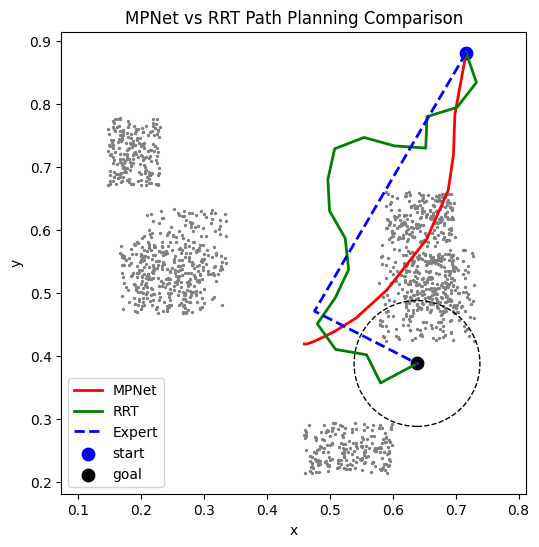

In [ ]:
import matplotlib.pyplot as plt

env_id = 1
case_id = 156

# load obs
obs = np.fromfile(f"../dataset/obs_cloud/obc{env_id}.dat")
obs_xy = obs.reshape(-1, 2)

# obs encode
obs_input = torch.from_numpy(obs).float().unsqueeze(0).to(device)
with torch.no_grad():
    obs_code = encoder(obs_input).squeeze(0)

# load expert
expert = np.fromfile(f"../dataset/e{env_id}/path{case_id}.dat").reshape(-1, 2)
start, goal = expert[0], expert[-1]

# MPNet
mpnet_path, _ = generate_path_fast(start, goal, obs_code)

# RRT
rrt_path, _ = rrt_plan(start, goal, obs_xy)

# plot
plt.figure(figsize=(6,6))

# obstacles
plt.scatter(obs_xy[:,0], obs_xy[:,1], s=2, c='gray')

# paths
plt.plot(mpnet_path[:,0], mpnet_path[:,1], 'r-', label='MPNet', linewidth=2)
if rrt_path is not None:
    plt.plot(rrt_path[:,0], rrt_path[:,1], 'g-', label='RRT', linewidth=2)

plt.plot(expert[:,0], expert[:,1], 'b--', label='Expert', linewidth=2)

# start & goal
plt.scatter(start[0], start[1], c='blue', s=80, label='start')
plt.scatter(goal[0], goal[1], c='black', s=80, label='goal')

# goal region
circle = plt.Circle(goal, 0.1, color='black', fill=False, linestyle='--')
plt.gca().add_patch(circle)

plt.legend()
plt.title("MPNet vs RRT Path Planning Comparison")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")

plt.savefig("/content/drive/MyDrive/exp1_mpnet_vs_rrt.png", dpi=300)
plt.show()

In [ ]:
# ===== 自动寻找 MPNet 和 RRT 都成功的 case =====

success_case = None

env_id = 1

obs = np.fromfile(f"../dataset/obs_cloud/obc{env_id}.dat")
obs_xy = obs.reshape(-1, 2)

obs_input = torch.from_numpy(obs).float().unsqueeze(0).to(device)
with torch.no_grad():
    obs_code = encoder(obs_input).squeeze(0)

for case_id in range(50):
    expert = np.fromfile(f"../dataset/e{env_id}/path{case_id}.dat").reshape(-1, 2)
    start, goal = expert[0], expert[-1]

    # MPNet
    mpnet_path, mpnet_dist = generate_path_improved(start, goal, obs_code)
    mpnet_plot_path = np.vstack([mpnet_path, goal])
    mpnet_collision = check_collision_strict(mpnet_plot_path, obs_xy)
    mpnet_success = (mpnet_dist < 0.1) and (not mpnet_collision)

    # RRT
    rrt_path, rrt_found = rrt_plan(start, goal, obs_xy)
    if rrt_found:
        rrt_collision = check_collision_strict(rrt_path, obs_xy)
        rrt_success = not rrt_collision
    else:
        rrt_collision = True
        rrt_success = False

    if mpnet_success and rrt_success:
        success_case = {
            "case_id": case_id,
            "expert": expert,
            "start": start,
            "goal": goal,
            "mpnet_path": mpnet_plot_path,
            "rrt_path": rrt_path,
            "mpnet_dist": mpnet_dist,
            "mpnet_len": path_length(mpnet_plot_path),
            "rrt_len": path_length(rrt_path)
        }
        print("Found success case:", case_id)
        print("MPNet final dist:", mpnet_dist)
        print("MPNet length:", path_length(mpnet_plot_path))
        print("RRT length:", path_length(rrt_path))
        break

if success_case is None:
    print("No shared success case found in first 50 cases. Try increasing range to 100.")

Found success case: 1
MPNet final dist: 0.09318894001690495
MPNet length: 0.3732903457138631
RRT length: 0.4905952698426035


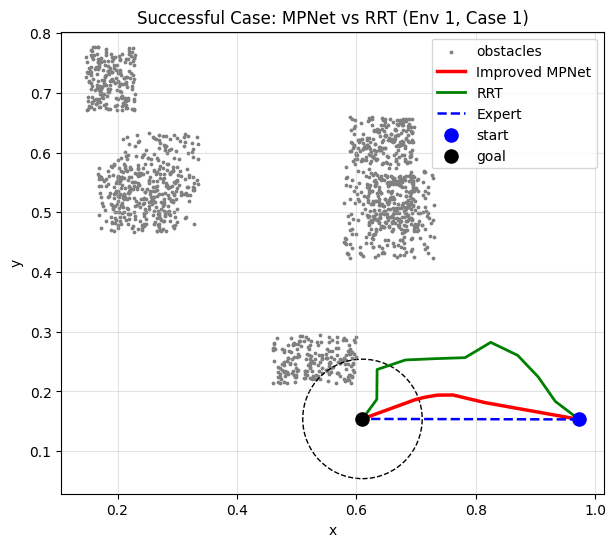

In [ ]:
# ===== 画成功 case 对比图 =====

c = success_case

plt.figure(figsize=(7, 6))

plt.scatter(obs_xy[:, 0], obs_xy[:, 1], s=3, c="gray", label="obstacles")

plt.plot(c["mpnet_path"][:, 0], c["mpnet_path"][:, 1], "r-", linewidth=2.5, label="Improved MPNet")
plt.plot(c["rrt_path"][:, 0], c["rrt_path"][:, 1], "g-", linewidth=2.0, label="RRT")
plt.plot(c["expert"][:, 0], c["expert"][:, 1], "b--", linewidth=1.8, label="Expert")

plt.scatter(c["start"][0], c["start"][1], c="blue", s=90, label="start", zorder=5)
plt.scatter(c["goal"][0], c["goal"][1], c="black", s=90, label="goal", zorder=5)

circle = plt.Circle(c["goal"], 0.1, color="black", fill=False, linestyle="--")
plt.gca().add_patch(circle)

plt.title(f"Successful Case: MPNet vs RRT (Env {env_id}, Case {c['case_id']})")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.axis("equal")
plt.grid(True, alpha=0.35)

plt.savefig("/content/drive/MyDrive/exp1_success_case_mpnet_rrt.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# ===== 找“跨过/绕过障碍物”的成功 case =====

good_cases = []

env_id = 1

obs = np.fromfile(f"../dataset/obs_cloud/obc{env_id}.dat")
obs_xy = obs.reshape(-1, 2)

obs_input = torch.from_numpy(obs).float().unsqueeze(0).to(device)
with torch.no_grad():
    obs_code = encoder(obs_input).squeeze(0)

for case_id in range(300):
    try:
        expert = np.fromfile(f"../dataset/e{env_id}/path{case_id}.dat").reshape(-1, 2)
    except:
        continue

    start, goal = expert[0], expert[-1]
    sg_dist = np.linalg.norm(goal - start)

    # 起终点太近不要
    if sg_dist < 0.45:
        continue

    # Improved MPNet
    mpnet_path, mpnet_dist = generate_path_improved(start, goal, obs_code)
    mpnet_plot_path = np.vstack([mpnet_path, goal])
    mpnet_collision = check_collision_strict(mpnet_plot_path, obs_xy)
    mpnet_success = (mpnet_dist < 0.1) and (not mpnet_collision)

    if not mpnet_success:
        continue

    # RRT
    rrt_path, rrt_found = rrt_plan(start, goal, obs_xy)
    if not rrt_found:
        continue

    rrt_collision = check_collision_strict(rrt_path, obs_xy)
    if rrt_collision:
        continue

    # 路径长度比直线长，说明不是简单直线
    mpnet_len = path_length(mpnet_plot_path)
    rrt_len = path_length(rrt_path)
    ratio = mpnet_len / (sg_dist + 1e-6)

    if ratio < 1.10:
        continue

    # 路径要靠近障碍，否则看不出避障
    min_clearance = min(
        np.min(np.linalg.norm(obs_xy - p, axis=1))
        for p in mpnet_plot_path
    )

    if min_clearance > 0.18:
        continue

    score = 2.0 * ratio + sg_dist - mpnet_dist - 0.5 * min_clearance

    good_cases.append({
        "score": score,
        "case_id": case_id,
        "expert": expert,
        "start": start,
        "goal": goal,
        "mpnet_path": mpnet_plot_path,
        "rrt_path": rrt_path,
        "mpnet_dist": mpnet_dist,
        "mpnet_len": mpnet_len,
        "rrt_len": rrt_len,
        "ratio": ratio,
        "clearance": min_clearance
    })

good_cases = sorted(good_cases, key=lambda x: x["score"], reverse=True)

print("Found good cases:", len(good_cases))

for c in good_cases[:10]:
    print(
        f"case {c['case_id']}, "
        f"score={c['score']:.3f}, "
        f"dist={c['mpnet_dist']:.3f}, "
        f"ratio={c['ratio']:.2f}, "
        f"clearance={c['clearance']:.3f}"
    )

Found good cases: 2
case 156, score=3.286, dist=0.092, ratio=1.45, clearance=0.038
case 35, score=2.767, dist=0.090, ratio=1.10, clearance=0.084


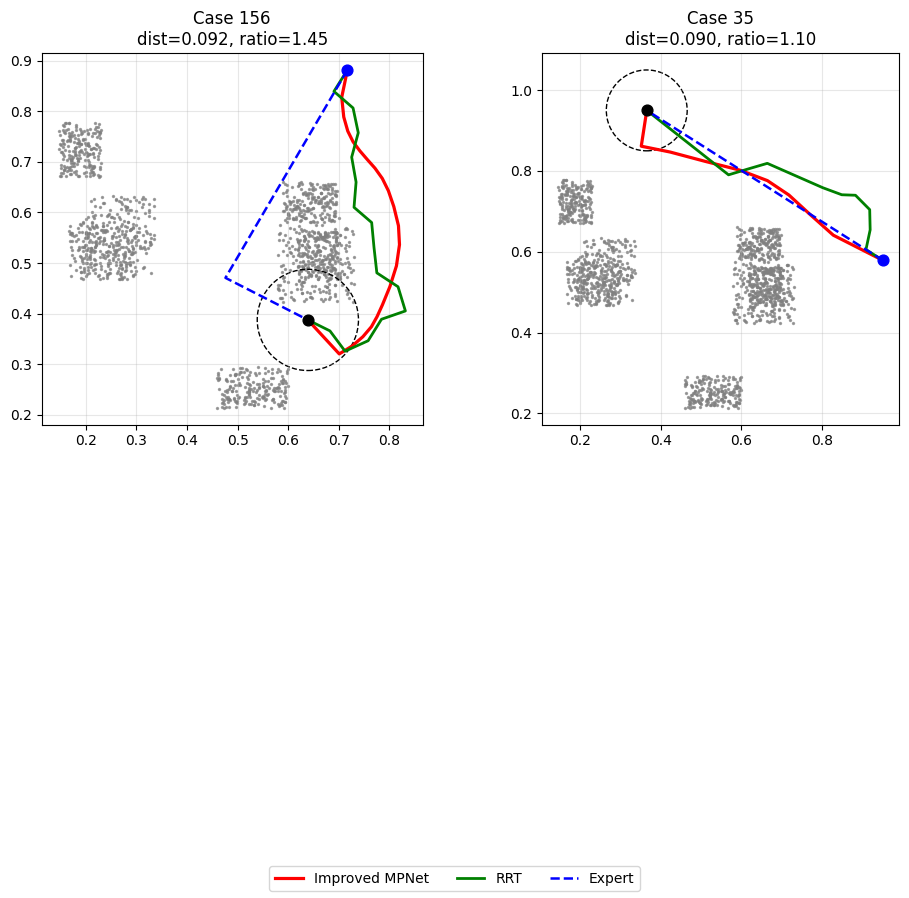

In [ ]:
top_k = min(6, len(good_cases))

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i in range(top_k):
    c = good_cases[i]
    ax = axes[i]

    ax.scatter(obs_xy[:, 0], obs_xy[:, 1], s=2, c="gray", alpha=0.7)

    ax.plot(c["mpnet_path"][:, 0], c["mpnet_path"][:, 1], "r-", linewidth=2.3, label="Improved MPNet")
    ax.plot(c["rrt_path"][:, 0], c["rrt_path"][:, 1], "g-", linewidth=2.0, label="RRT")
    ax.plot(c["expert"][:, 0], c["expert"][:, 1], "b--", linewidth=1.8, label="Expert")

    ax.scatter(c["start"][0], c["start"][1], c="blue", s=60, zorder=5)
    ax.scatter(c["goal"][0], c["goal"][1], c="black", s=60, zorder=5)

    circle = plt.Circle(c["goal"], 0.1, color="black", fill=False, linestyle="--")
    ax.add_patch(circle)

    ax.set_title(
        f"Case {c['case_id']}\n"
        f"dist={c['mpnet_dist']:.3f}, ratio={c['ratio']:.2f}"
    )

    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)

for i in range(top_k, len(axes)):
    fig.delaxes(axes[i])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("/content/drive/MyDrive/exp1_good_crossing_cases.png", dpi=300, bbox_inches="tight")
plt.show()

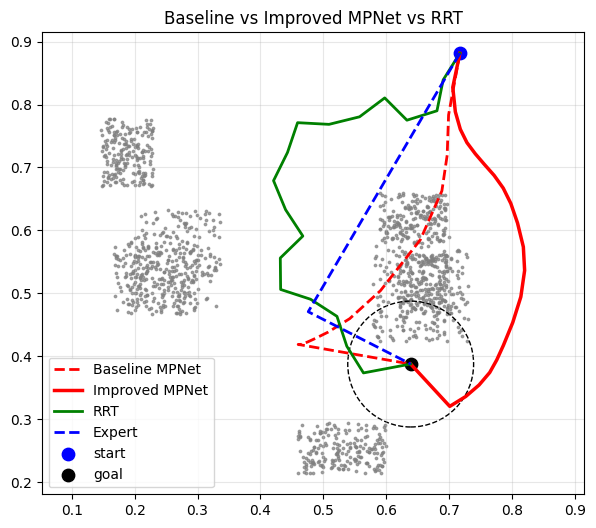

In [ ]:
# ===== 画 Baseline vs Improved vs RRT =====

env_id = 1
case_id = 156

# load data
obs = np.fromfile(f"../dataset/obs_cloud/obc{env_id}.dat")
obs_xy = obs.reshape(-1, 2)

obs_input = torch.from_numpy(obs).float().unsqueeze(0).to(device)
with torch.no_grad():
    obs_code = encoder(obs_input).squeeze(0)

expert = np.fromfile(f"../dataset/e{env_id}/path{case_id}.dat").reshape(-1, 2)
start, goal = expert[0], expert[-1]

# Baseline MPNet
baseline_path, _ = generate_path_fast(start, goal, obs_code)
baseline_path = np.vstack([baseline_path, goal])

# Improved MPNet
improved_path, _ = generate_path_improved(start, goal, obs_code)
improved_path = np.vstack([improved_path, goal])

# RRT
rrt_path, _ = rrt_plan(start, goal, obs_xy)

# ===== plot =====
plt.figure(figsize=(7,6))

plt.scatter(obs_xy[:,0], obs_xy[:,1], s=3, c='gray', alpha=0.7)

plt.plot(baseline_path[:,0], baseline_path[:,1], 'r--', linewidth=2, label='Baseline MPNet')
plt.plot(improved_path[:,0], improved_path[:,1], 'r-', linewidth=2.5, label='Improved MPNet')

if rrt_path is not None:
    plt.plot(rrt_path[:,0], rrt_path[:,1], 'g-', linewidth=2, label='RRT')

plt.plot(expert[:,0], expert[:,1], 'b--', linewidth=2, label='Expert')

plt.scatter(start[0], start[1], c='blue', s=80, label='start')
plt.scatter(goal[0], goal[1], c='black', s=80, label='goal')

circle = plt.Circle(goal, 0.1, color='black', fill=False, linestyle='--')
plt.gca().add_patch(circle)

plt.title("Baseline vs Improved MPNet vs RRT")
plt.legend()
plt.axis("equal")
plt.grid(True, alpha=0.3)

plt.savefig("/content/drive/MyDrive/exp1_full_comparison.png", dpi=300)
plt.show()

In [76]:
def plot_case_with_avg_time(start, goal, expert, mpnet_path, rrt_path,
                           obs_xy, title, save_name):

    plt.figure(figsize=(7,6))

    plt.scatter(obs_xy[:,0], obs_xy[:,1], s=3, c='gray', alpha=0.7)

    plt.plot(mpnet_path[:,0], mpnet_path[:,1], 'r-', linewidth=2.5, label='MPNet')
    if rrt_path is not None:
        plt.plot(rrt_path[:,0], rrt_path[:,1], 'g-', linewidth=2, label='RRT')

    plt.plot(expert[:,0], expert[:,1], 'b--', linewidth=2, label='Expert')

    plt.scatter(start[0], start[1], c='blue', s=90, label='start')
    plt.scatter(goal[0], goal[1], c='black', s=90, label='goal')

    circle = plt.Circle(goal, 0.1, color='black', fill=False, linestyle='--')
    plt.gca().add_patch(circle)

    # ✅ 平均时间
    plt.text(0.02, 0.95, "MPNet (avg): 0.073s", transform=plt.gca().transAxes)
    plt.text(0.02, 0.90, "RRT (avg): 0.699s", transform=plt.gca().transAxes)

    plt.title(title)
    plt.legend()
    plt.axis("equal")
    plt.grid(True, alpha=0.3)

    plt.savefig(f"/content/drive/MyDrive/{save_name}", dpi=300, bbox_inches='tight')
    plt.show()